In [7]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'scripts' else Path.cwd()
DATASET_PATH = REPO_ROOT / 'data' / 'dataset' / 'numina_math_1_5.jsonl'

records = []
with DATASET_PATH.open() as file:
    for line in file:
        records.append(json.loads(line))

df = pd.DataFrame(records)
print(f'Loaded {len(df):,} problems from {DATASET_PATH}')
df[['source', 'question_type', 'problem_type']].head()


Loaded 896,215 problems from /Users/magn3144/Documents/GitHub/AlphaProof/data/dataset/numina_math_1_5.jsonl


,source,question_type,problem_type
0,olympiads,math-word-problem,Number Theory
1,olympiads,proof,Algebra
2,olympiads,proof,Geometry
3,olympiads,math-word-problem,Combinatorics
4,olympiads,proof,Geometry


In [8]:
source_counts = df['source'].value_counts().sort_values()
question_type_counts = df['question_type'].value_counts().sort_values()
problem_type_counts = df['problem_type'].value_counts().sort_values()
source_question_counts = pd.crosstab(df['source'], df['question_type'])

display(source_counts.sort_values(ascending=False).to_frame('problems'))
display(question_type_counts.sort_values(ascending=False).to_frame('problems'))
display(problem_type_counts.sort_values(ascending=False).to_frame('problems'))
display(source_question_counts)


,problems
source,
cn_k12,268819
olympiads,197084
orca_math,151934
synthetic_math,148712
aops_forum,67841
cn_contest,29944
metamath,11014
inequalities,7314
amc_aime,5872


,problems
question_type,
math-word-problem,631522
MCQ,146449
proof,110998
NaN,5216
other,2030


,problems
problem_type,
Algebra,422915
Geometry,183796
Number Theory,91383
Combinatorics,73643
Inequalities,41741
Logic and Puzzles,37911
Calculus,26965
Other,12645
NaN,5216


question_type,MCQ,NaN,math-word-problem,other,proof
source,,,,,
amc_aime,4374,327,963,0,208
aops_forum,5924,2048,33486,1851,24532
cn_contest,5602,8,15649,22,8663
cn_k12,115800,5,149010,38,3966
inequalities,49,0,1478,7,5780
metamath,82,0,10932,0,0
number_theory,15,197,1239,1,2591
olympiads,13529,2631,117845,109,62970
olympiads_ref,0,0,1392,0,2246


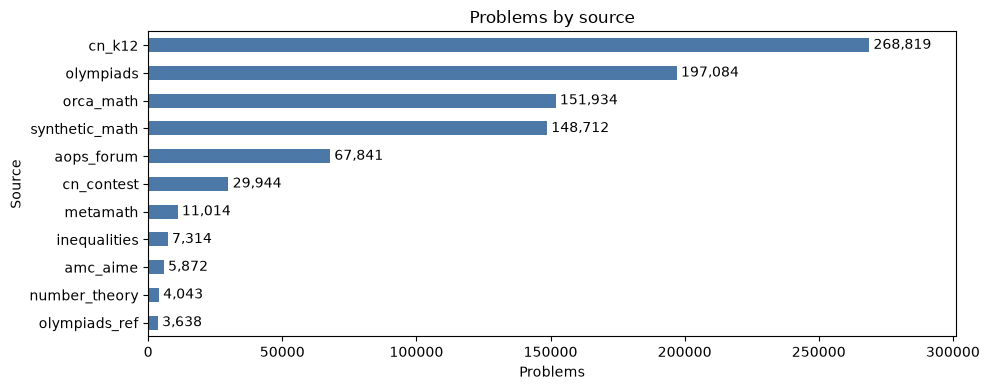

In [9]:
fig, ax = plt.subplots(figsize=(10, max(4, 0.35 * len(source_counts))))
source_counts.plot(kind='barh', ax=ax, color='#4c78a8')

ax.set_title('Problems by source')
ax.set_xlabel('Problems')
ax.set_ylabel('Source')
ax.bar_label(ax.containers[0], padding=3, fmt='{:,.0f}')
ax.margins(x=0.12)
fig.tight_layout()


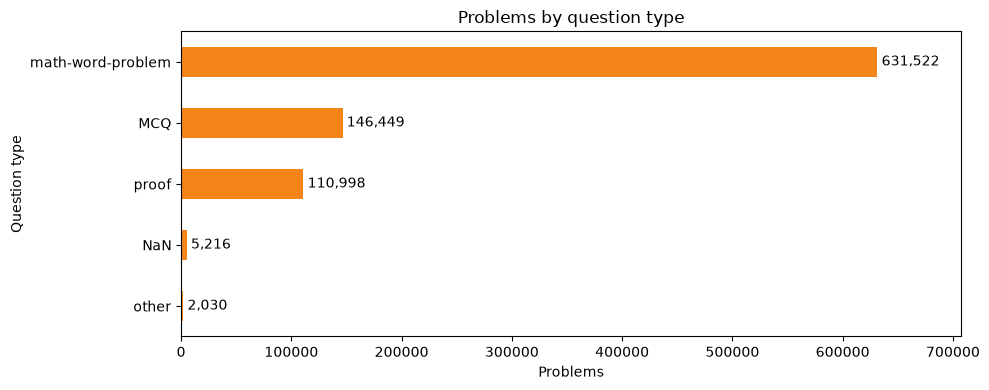

In [10]:
fig, ax = plt.subplots(figsize=(10, max(4, 0.45 * len(question_type_counts))))
question_type_counts.plot(kind='barh', ax=ax, color='#f58518')

ax.set_title('Problems by question type')
ax.set_xlabel('Problems')
ax.set_ylabel('Question type')
ax.bar_label(ax.containers[0], padding=3, fmt='{:,.0f}')
ax.margins(x=0.12)
fig.tight_layout()


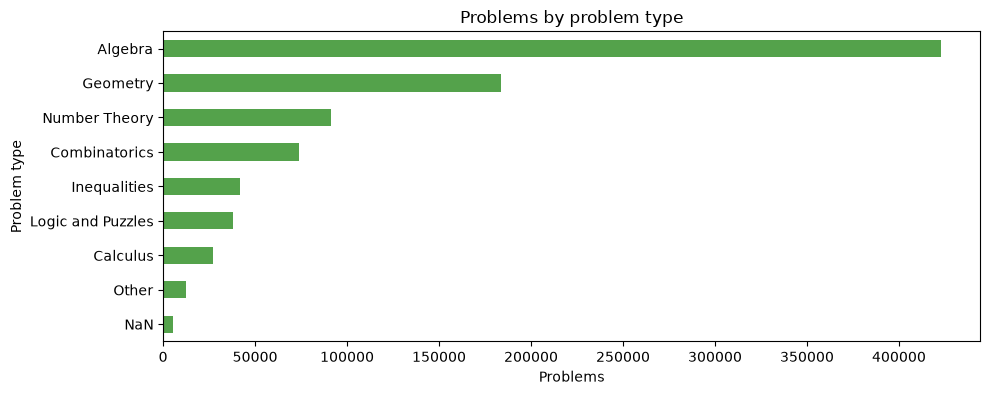

In [11]:
fig, ax = plt.subplots(figsize=(10, max(4, 0.45 * len(problem_type_counts))))
problem_type_counts.plot(kind='barh', ax=ax, color='#54a24b')

ax.set_title('Problems by problem type')
ax.set_xlabel('Problems')
ax.set_ylabel('Problem type')
fig.tight_layout()


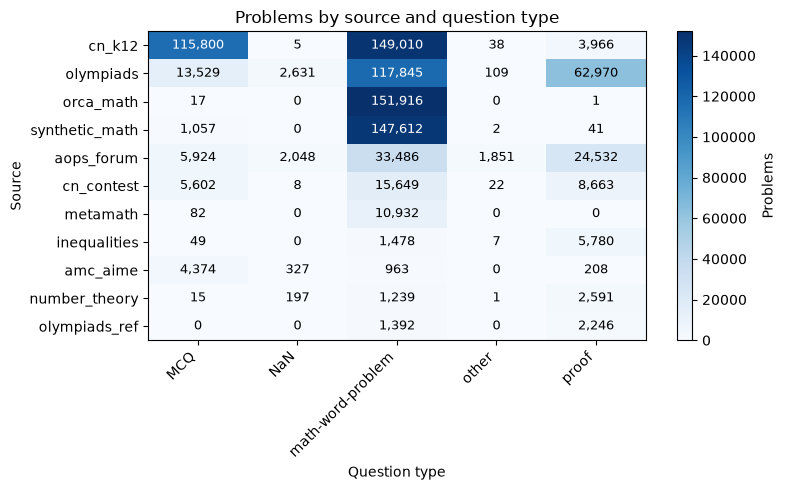

In [12]:
plot_table = source_question_counts.loc[source_counts.index[::-1]]

fig, ax = plt.subplots(
    figsize=(max(8, 1.25 * len(plot_table.columns)), max(5, 0.45 * len(plot_table)))
)
image = ax.imshow(plot_table, cmap='Blues', aspect='auto')

ax.set_title('Problems by source and question type')
ax.set_xlabel('Question type')
ax.set_ylabel('Source')
ax.set_xticks(range(len(plot_table.columns)), plot_table.columns, rotation=45, ha='right')
ax.set_yticks(range(len(plot_table.index)), plot_table.index)

max_count = plot_table.to_numpy().max()
label_threshold = max_count / 2
for row_ix, source in enumerate(plot_table.index):
    for col_ix, question_type in enumerate(plot_table.columns):
        count = plot_table.loc[source, question_type]
        color = 'white' if count > label_threshold else 'black'
        ax.text(col_ix, row_ix, f'{count:,}', ha='center', va='center', color=color, fontsize=9)

fig.colorbar(image, ax=ax, label='Problems')
fig.tight_layout()


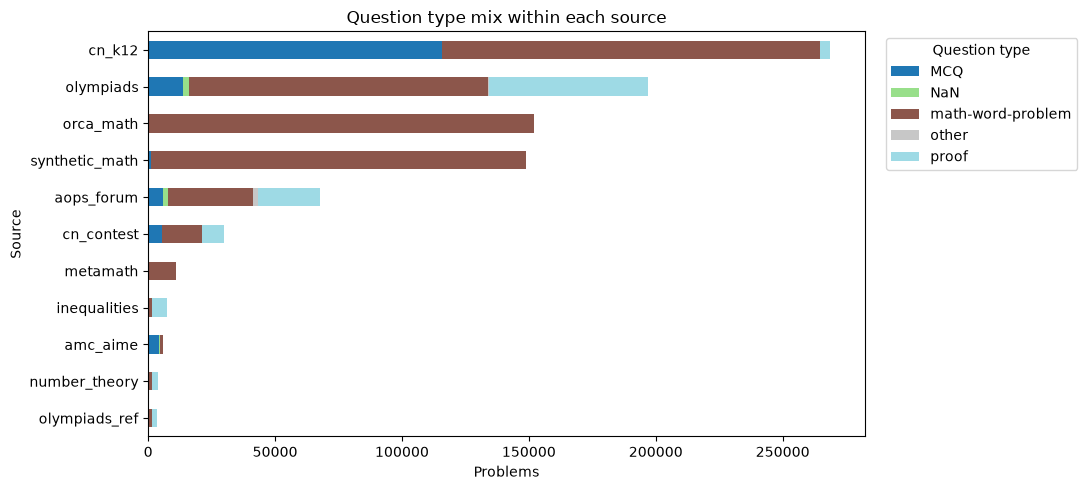

In [13]:
stacked_counts = source_question_counts.loc[source_counts.index]

fig, ax = plt.subplots(figsize=(11, max(5, 0.45 * len(stacked_counts))))
stacked_counts.plot(kind='barh', stacked=True, ax=ax, colormap='tab20')

ax.set_title('Question type mix within each source')
ax.set_xlabel('Problems')
ax.set_ylabel('Source')
ax.legend(title='Question type', bbox_to_anchor=(1.02, 1), loc='upper left')
fig.tight_layout()
